In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [138]:
"""Data Visualization"""
sns.set_theme(style="whitegrid")
df = pd.read_csv('../data/raw/blkjckhands.csv')
print(f"Toplam Satır: {df.shape[0]:,}, Toplam Sütun: {df.shape[1]}")
display(df.head())

Toplam Satır: 900,000, Toplam Sütun: 21


,Unnamed: 0,PlayerNo,card1,card2,card3,card4,card5,sumofcards,dealcard1,dealcard2,...,dealcard4,dealcard5,sumofdeal,blkjck,winloss,plybustbeat,dlbustbeat,plwinamt,dlwinamt,ply2cardsum
0,0,Player1,7,10,0,0,0,17,10,8,...,0,0,18,nowin,Loss,Beat,Dlwin,0,10,17
1,1,Player2,10,9,0,0,0,19,10,8,...,0,0,18,nowin,Win,Plwin,Beat,20,0,19
2,2,Player3,9,8,0,0,0,17,10,8,...,0,0,18,nowin,Loss,Beat,Dlwin,0,10,17
3,3,Player4,2,10,0,5,0,17,10,8,...,0,0,18,nowin,Loss,Beat,Dlwin,0,10,12
4,4,Player5,10,2,0,5,0,17,10,8,...,0,0,18,nowin,Loss,Beat,Dlwin,0,10,12


In [139]:
"""Null data checking"""
df.info()
print("\n--- Boş Veri Kontrolü ---")
print(df.isnull().sum())
display(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Unnamed: 0   900000 non-null  int64
 1   PlayerNo     900000 non-null  str  
 2   card1        900000 non-null  int64
 3   card2        900000 non-null  int64
 4   card3        900000 non-null  int64
 5   card4        900000 non-null  int64
 6   card5        900000 non-null  int64
 7   sumofcards   900000 non-null  int64
 8   dealcard1    900000 non-null  int64
 9   dealcard2    900000 non-null  int64
 10  dealcard3    900000 non-null  int64
 11  dealcard4    900000 non-null  int64
 12  dealcard5    900000 non-null  int64
 13  sumofdeal    900000 non-null  int64
 14  blkjck       900000 non-null  str  
 15  winloss      900000 non-null  str  
 16  plybustbeat  900000 non-null  str  
 17  dlbustbeat   900000 non-null  str  
 18  plwinamt     900000 non-null  int64
 19  dlwinamt     900000 non-null  int6

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,900000.0,2.500000,1.707826,0.0,1.0,2.5,4.0,5.0
card1,900000.0,7.126259,2.994719,1.0,5.0,8.0,10.0,11.0
card2,900000.0,7.089927,3.008032,1.0,4.0,8.0,10.0,11.0
card3,900000.0,1.955088,3.531830,0.0,0.0,0.0,2.0,11.0
card4,900000.0,2.336462,3.657284,0.0,0.0,0.0,4.0,10.0
card5,900000.0,0.389787,1.730740,0.0,0.0,0.0,0.0,10.0
sumofcards,900000.0,18.897522,3.210611,8.0,17.0,19.0,21.0,26.0
dealcard1,900000.0,7.170380,2.981575,1.0,5.0,8.0,10.0,11.0
dealcard2,900000.0,7.129867,2.990306,1.0,5.0,8.0,10.0,11.0
dealcard3,900000.0,4.391293,4.080103,0.0,0.0,4.0,9.0,11.0


C:\Users\pc\AppData\Local\Temp\ipykernel_21708\3065096140.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='winloss', data=df, palette='viridis')


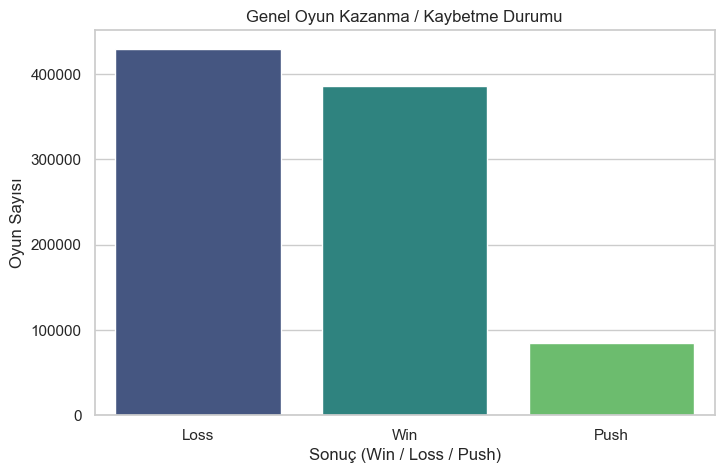

--- Sonuç Dağılımı ---
winloss
Loss    47.757889
Win     42.882889
Push     9.359222
Name: proportion, dtype: float64


In [140]:
"""Game Win/Loss Analysis"""
plt.figure(figsize=(8, 5))
sns.countplot(x='winloss', data=df, palette='viridis')
plt.title('Genel Oyun Kazanma / Kaybetme Durumu')
plt.xlabel('Sonuç (Win / Loss / Push)')
plt.ylabel('Oyun Sayısı')
plt.show()
print("--- Sonuç Dağılımı ---")
print(df['winloss'].value_counts(normalize=True) * 100)

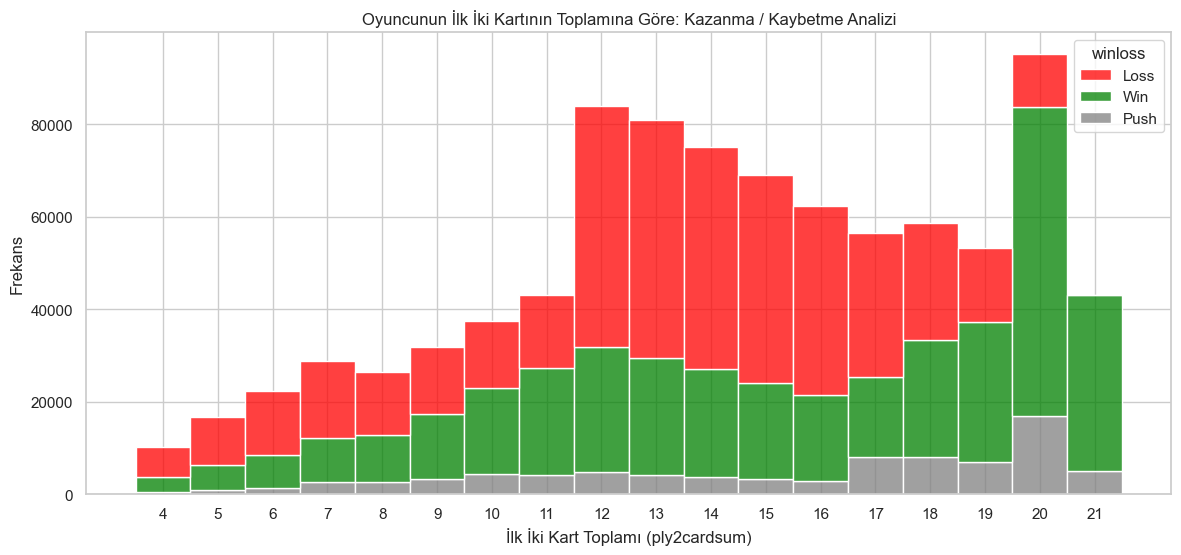

In [141]:
"""Game Win Condition Due To First 2 Cards"""
plt.figure(figsize=(14, 6))
sns.histplot(
    data=df, x='ply2cardsum', hue='winloss', multiple='stack', 
    palette={'Win': 'green', 'Loss': 'red', 'Push': 'gray'}, 
    bins=[x + 0.5 for x in range(3, 22)], kde=False
)
plt.title('Oyuncunun İlk İki Kartının Toplamına Göre: Kazanma / Kaybetme Analizi')
plt.xlabel('İlk İki Kart Toplamı (ply2cardsum)')
plt.ylabel('Frekans')
plt.xticks(range(4,22))
plt.show()

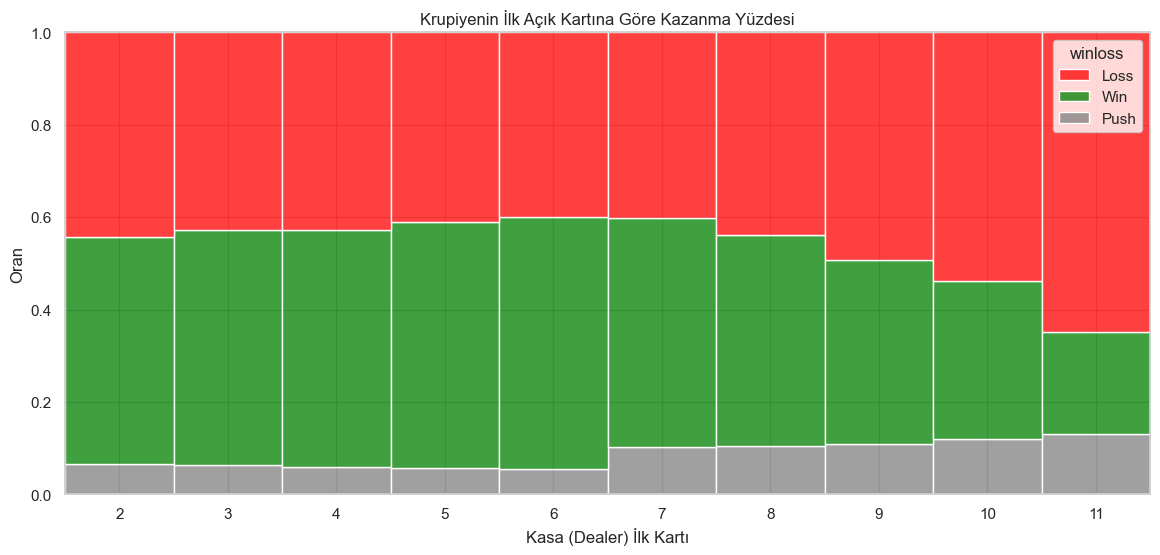

In [142]:
"""Dealer's First Card's Effect"""
plt.figure(figsize=(14, 6))
sns.histplot(
    data=df, x='dealcard1', hue='winloss', multiple='fill', 
    palette={'Win': 'green', 'Loss': 'red', 'Push': 'gray'}, 
    bins=[x + 0.5 for x  in range(1, 12, 1)]
)
plt.title('Krupiyenin İlk Açık Kartına Göre Kazanma Yüzdesi')
plt.xlabel('Kasa (Dealer) İlk Kartı')
plt.ylabel('Oran')
plt.xticks(range(2, 12))
plt.show()

In [148]:
hatali_eller = dh[(dh['dealcard5'] != 0) & (dh['sumofdeal'] < 17)]
len(hatali_eller) # Şimdi size doğru sayıyı verecektir.


0